# BrushCue Example: Halftone

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/halftone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/halftone

In [ ]:
!pip install brushcue

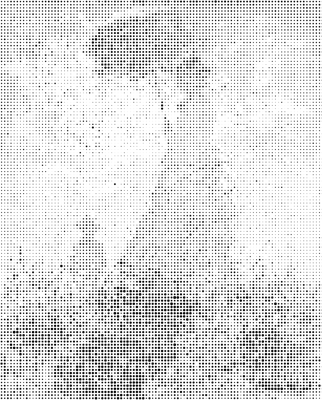

In [1]:
import brushcue
from PIL import Image
import io

image_input_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("let pix_size = u32(pixel_size);\nlet block_corner = (position / pix_size) * pix_size;\nlet center_coord = block_corner + pix_size / 2u;\nlet result = textureLoad(input_texture, center_coord, 0);\nlet distance_from_center = length(vec2<f32>(position) - vec2<f32>(center_coord));\nlet max_radius = f32(pix_size / 2);\nlet lightness_scale = 1.0 - clamp(result.x, 0.0, 1.0);\nlet pixel_radius = max_radius * lightness_scale;\nif (distance_from_center < pixel_radius) {\n  return foreground_color;\n} else {\n  return background_color;\n}\nreturn vec4<f32>(0.0);")
string_constant_3 = brushcue.string_constant("// No helpers for this tool.")
color_profile_oklaba_4 = brushcue.color_profile_ok_lab_a()
color_profile_srgb_5 = brushcue.color_profile_s_r_g_b()
bool_constant_6 = brushcue.bool_constant(False)
curve_pivoted_sigmoid_7 = brushcue.curve_pivoted_sigmoid(0.5, 2.0)
string_constant_8 = brushcue.string_constant("background_color")
rgba_color_constant_9 = brushcue.r_g_b_a_color_constant(1, 1, 1, 1)
string_constant_10 = brushcue.string_constant("foreground_color")
rgba_color_constant_11 = brushcue.r_g_b_a_color_constant(0, 0, 0, 1)
dictionary_create_12 = brushcue.dictionary_create()
string_constant_13 = brushcue.string_constant("pixel_size")
composition_lightness_curve_14 = brushcue.composition_l_curve(image_input_1, curve_pivoted_sigmoid_7)
int_add_to_dictionary_15 = brushcue.int_add_to_dictionary(dictionary_create_12, string_constant_13, 17)
rgba_color_add_to_dictionary_16 = brushcue.r_g_b_a_color_add_to_dictionary(int_add_to_dictionary_15, string_constant_10, rgba_color_constant_11)
rgba_color_add_to_dictionary_17 = brushcue.r_g_b_a_color_add_to_dictionary(rgba_color_add_to_dictionary_16, string_constant_8, rgba_color_constant_9)
halftone_shader_18 = brushcue.composition_custom_transformer_shader(composition_lightness_curve_14, string_constant_2, string_constant_3, color_profile_oklaba_4, color_profile_srgb_5, rgba_color_add_to_dictionary_17, bool_constant_6)

ctx = brushcue.Context()
result = halftone_shader_18.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
